In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_excel('Pet_Weight_Prediction_Dataset.csv')
df.head()

,PetAge_Years,PetWeight_kg
0,9.8,22.2
1,4.5,11.3
2,11.2,27.8
3,13.4,30.3
4,6.6,15.1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PetAge_Years  80 non-null     float64
 1   PetWeight_kg  80 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


,PetAge_Years,PetWeight_kg
count,80.000000,80.000000
mean,7.647500,19.203750
std,4.514589,10.168074
min,0.500000,2.900000
25%,3.775000,10.525000
50%,7.250000,18.700000
75%,12.050000,28.600000
max,15.000000,36.100000


In [4]:
X = df[['PetAge_Years']]
y = df['PetWeight_kg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
y_pred = model.predict(X_test)

slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R2 Score: {r2}")
print(f"MSE: {mse}")

Slope: 2.2464614824639844
Intercept: 1.9745509125628722
R2 Score: 0.9884170106828868
MSE: 1.3966438222395314


C:\Users\VITHYA SRI .S\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


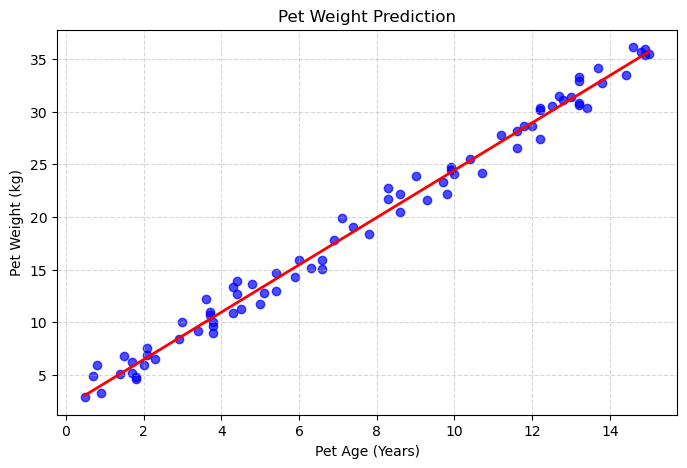

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.7)

x_range = np.linspace(X['PetAge_Years'].min(), X['PetAge_Years'].max(), 100).reshape(-1, 1)
y_range_pred = model.predict(x_range)

plt.plot(x_range, y_range_pred, color='red', linewidth=2)
plt.title('Pet Weight Prediction')
plt.xlabel('Pet Age (Years)')
plt.ylabel('Pet Weight (kg)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
new_age = pd.DataFrame({'PetAge_Years': [5.0]})
predicted_weight = model.predict(new_age)
print(predicted_weight[0])

13.206858324882795
